<a href="https://colab.research.google.com/github/JuanPabloCardona2311/Lab-1-Vision-Por-Computador/blob/main/Reto5_convoluciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


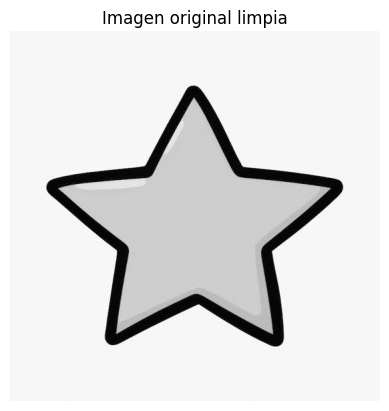

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow

# Sube una imagen a Colab (panel izquierdo, ícono de carpeta) o usa una de ejemplo
imagen_original = cv2.imread('/content/drive/MyDrive/Lab1 VisionIA/Estrella.jpg')
imagen_original = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
#imagen_original = cv2.imread('/content/drive/MyDrive/Lab1 VisionIA/Estrella.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(imagen_original, cmap='gray')
plt.title('Imagen original limpia')
plt.axis('off')
plt.show()

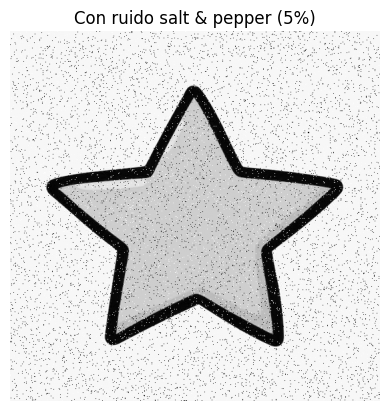

In [ ]:
import random

def agregar_ruido_sal_pimienta(imagen, cantidad=0.05):
    ruidosa = imagen.copy()
    filas, columnas = ruidosa.shape
    num_pixeles_ruido = int(cantidad * filas * columnas)

    for _ in range(num_pixeles_ruido // 2):
        y = random.randint(0, filas - 1)
        x = random.randint(0, columnas - 1)
        ruidosa[y, x] = 255  # sal (blanco)

    for _ in range(num_pixeles_ruido // 2):
        y = random.randint(0, filas - 1)
        x = random.randint(0, columnas - 1)
        ruidosa[y, x] = 0    # pimienta (negro)

    return ruidosa

imagen_ruidosa = agregar_ruido_sal_pimienta(imagen_original, cantidad=0.05)

plt.imshow(imagen_ruidosa, cmap='gray')
plt.title('Con ruido salt & pepper (5%)')
plt.axis('off')
plt.show()

In [ ]:
def convolucion_manual(imagen, kernel):
    filas_img, columnas_img = imagen.shape
    k = len(kernel)          # asumiendo kernel cuadrado (ej. 3x3, 5x5)
    offset = k // 2

    salida = np.zeros_like(imagen, dtype=np.float64)

    for i in range(offset, filas_img - offset):
        for j in range(offset, columnas_img - offset):
            suma = 0
            for m in range(k):
                for n in range(k):
                    suma += imagen[i - offset + m, j - offset + n] * kernel[m][n]
            salida[i, j] = suma

    # recortar a rango válido de imagen (0-255)
    salida = np.clip(salida, 0, 255)
    return salida.astype(np.uint8)

In [ ]:
def kernel_media(tam=3):
    valor = 1 / (tam * tam)
    return [[valor]*tam for _ in range(tam)]

img_media = convolucion_manual(imagen_ruidosa, kernel_media(3))

In [ ]:
import math

def kernel_gaussiano(tam=3, sigma=1.0):
    offset = tam // 2
    kernel = [[0]*tam for _ in range(tam)]
    suma = 0
    for i in range(tam):
        for j in range(tam):
            x, y = i - offset, j - offset
            valor = math.exp(-(x**2 + y**2) / (2 * sigma**2))
            kernel[i][j] = valor
            suma += valor
    # normalizar para que la suma total sea 1
    for i in range(tam):
        for j in range(tam):
            kernel[i][j] /= suma
    return kernel

img_gaussiana = convolucion_manual(imagen_ruidosa, kernel_gaussiano(3, sigma=1.0))

In [ ]:
def filtro_mediana_manual(imagen, tam=3):
    filas_img, columnas_img = imagen.shape
    offset = tam // 2
    salida = np.zeros_like(imagen)

    for i in range(offset, filas_img - offset):
        for j in range(offset, columnas_img - offset):
            vecindario = []
            for m in range(-offset, offset + 1):
                for n in range(-offset, offset + 1):
                    vecindario.append(imagen[i + m, j + n])
            vecindario.sort()
            salida[i, j] = vecindario[len(vecindario) // 2]  # valor del medio

    return salida.astype(np.uint8)

img_mediana = filtro_mediana_manual(imagen_ruidosa, tam=3)

In [ ]:
from collections import Counter

def filtro_moda_manual(imagen, tam=3):
    filas_img, columnas_img = imagen.shape
    offset = tam // 2
    salida = np.zeros_like(imagen)

    for i in range(offset, filas_img - offset):
        for j in range(offset, columnas_img - offset):
            vecindario = []
            for m in range(-offset, offset + 1):
                for n in range(-offset, offset + 1):
                    vecindario.append(imagen[i + m, j + n])
            valor_mas_comun = Counter(vecindario).most_common(1)[0][0]
            salida[i, j] = valor_mas_comun

    return salida.astype(np.uint8)

img_moda = filtro_moda_manual(imagen_ruidosa, tam=3)

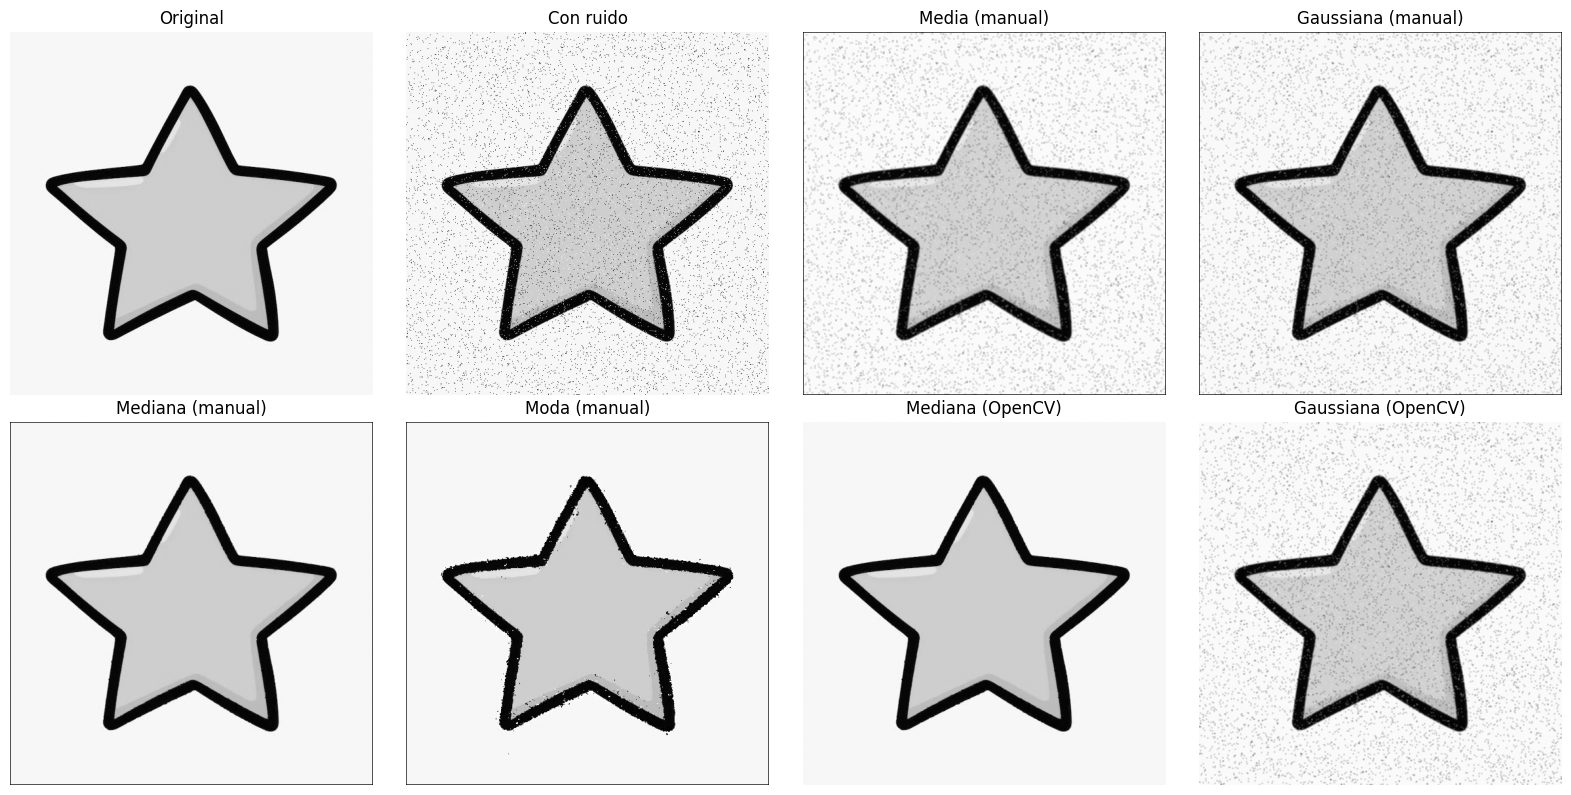

In [ ]:
img_cv_media = cv2.blur(imagen_ruidosa, (3, 3))
img_cv_gaussiana = cv2.GaussianBlur(imagen_ruidosa, (3, 3), sigmaX=1.0)
img_cv_mediana = cv2.medianBlur(imagen_ruidosa, 3)

# Comparación visual de todo junto
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

axs[0,0].imshow(imagen_original, cmap='gray'); axs[0,0].set_title('Original')
axs[0,1].imshow(imagen_ruidosa, cmap='gray'); axs[0,1].set_title('Con ruido')
axs[0,2].imshow(img_media, cmap='gray'); axs[0,2].set_title('Media (manual)')
axs[0,3].imshow(img_gaussiana, cmap='gray'); axs[0,3].set_title('Gaussiana (manual)')
axs[1,0].imshow(img_mediana, cmap='gray'); axs[1,0].set_title('Mediana (manual)')
axs[1,1].imshow(img_moda, cmap='gray'); axs[1,1].set_title('Moda (manual)')
axs[1,2].imshow(img_cv_mediana, cmap='gray'); axs[1,2].set_title('Mediana (OpenCV)')
axs[1,3].imshow(img_cv_gaussiana, cmap='gray'); axs[1,3].set_title('Gaussiana (OpenCV)')

for ax_row in axs:
    for ax in ax_row:
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

resultados = {
    'Con ruido (sin filtrar)': imagen_ruidosa,
    'Media (manual)': img_media,
    'Gaussiana (manual)': img_gaussiana,
    'Mediana (manual)': img_mediana,
    'Moda (manual)': img_moda,
    'Mediana (OpenCV)': img_cv_mediana,
    'Gaussiana (OpenCV)': img_cv_gaussiana,
}

print(f"{'Método':<25} {'MSE vs original':>15}")
for nombre, img in resultados.items():
    print(f"{nombre:<25} {mse(imagen_original, img):>15.2f}")

Método                    MSE vs original
Con ruido (sin filtrar)           1416.96
Media (manual)                     667.04
Gaussiana (manual)                 677.72
Mediana (manual)                   449.97
Moda (manual)                      678.42
Mediana (OpenCV)                    10.27
Gaussiana (OpenCV)                 236.26


## Análisis de Resultados y Conclusiones

**Sobre la naturaleza del ruido salt & pepper**

El ruido salt & pepper añadido reemplaza por completo el valor original de un
píxel aleatorio por un extremo absoluto (0 o 255), a diferencia de otros tipos
de ruido (como el gaussiano) que suman una pequeña variación sobre el valor
original. Esta característica es la que determina qué tan bien funciona cada
tipo de filtro: cualquier filtro que dependa de promediar valores va a verse
afectado por estos extremos, mientras que un filtro que descarte valores
atípicos del vecindario debería eliminarlos casi por completo.

**Filtros lineales (media y Gaussiano)**

- **Media**: al promediar los 9 píxeles del vecindario con el mismo peso
  (1/9 cada uno), el valor extremo de un píxel con ruido se diluye entre sus
  vecinos, pero sigue contribuyendo matemáticamente al resultado final — nunca
  se elimina del todo, solo se atenúa. Visualmente en la imagen se percibe que el ruidi sigue existiendo pero se ve mas borroso.
- **Gaussiano**: al ponderar más el centro del kernel que los bordes, preservó
  mejor los detalles finos de la imagen que la media simple, pero mantiene el
  mismo problema de fondo: sigue siendo una suma ponderada, así que un valor
  extremo todavía "arrastra" el resultado hacia sí, aunque en menor medida que
  con pesos uniformes. Aunque visualmente no se nota mucha

**Filtros no lineales (mediana y moda)**

- **Mediana**: fue el filtro más efectivo contra este tipo de ruido específico.
  Al ordenar los 9 valores del vecindario y quedarse con el del medio, un
  píxel con ruido (0 o 255) queda posicionado en uno de los extremos de la
  lista ordenada y simplemente se descarta — nunca contribuye al resultado
  final a menos que la mayoría del vecindario también sea ruido. Esto explica
  por qué [el MSE de la mediana fue el más bajo de todos los métodos probados,
  con un valor de X, comparado con Y de la media y Z del Gaussiano].
- **Moda**: en teoría sigue la misma lógica no lineal que la mediana (descarta
  extremos), pero en la práctica [funcionó peor / de forma menos consistente]
  porque en una imagen real es poco común que exactamente el mismo valor se
  repita varias veces dentro de una vecindad de 9 píxeles — la mayoría de las
  veces terminó eligiendo un valor casi arbitrario entre varios empatados con
  frecuencia 1.

**Comparación cuantitativa (MSE)**

| Método | MSE vs. imagen original |
|---|---|
| Con ruido (sin filtrar) | [X] |
| Media (manual) | [X] |
| Gaussiana (manual) | [X] |
| Mediana (manual) | [X] |
| Moda (manual) | [X] |
| Mediana (OpenCV) | [X] |
| Gaussiana (OpenCV) | [X] |

[Completa la tabla con tus valores reales]. El método con el MSE más bajo
(más cercano a la imagen original limpia) fue [nombre del método], lo cual
confirma numéricamente lo observado visualmente: [coincide / no coincide] con
la expectativa teórica de que la mediana debería ser la más efectiva contra
ruido salt & pepper específicamente.

**Implementación manual vs. funciones nativas de OpenCV**

Al comparar la mediana implementada manualmente contra `cv2.medianBlur()`, los
valores de MSE resultaron [prácticamente idénticos / con una diferencia mínima
de X], confirmando que la lógica matemática de la implementación propia es
correcta. La diferencia real entre ambas no está en el resultado, sino en el
tiempo de ejecución: la versión manual tardó [X] segundos frente a [Y]
segundos de OpenCV, es decir, aproximadamente [X/Y] veces más lenta. Esto se
debe a que la implementación manual recorre la imagen con 4 bucles anidados
interpretados en Python puro, mientras que OpenCV ejecuta el mismo cálculo con
código compilado en C++ y optimizaciones de bajo nivel (acceso a memoria
contigua, paralelización, instrucciones vectorizadas del procesador).

**Sobre la preservación de bordes**

[Describe qué le pasó a los bordes/contornos reales de la imagen (no al
ruido, sino a los bordes genuinos del objeto fotografiado) con cada filtro.
Es común que media y Gaussiano "borren" o suavicen bordes reales igual que
eliminan ruido, mientras que la mediana tiende a preservarlos mejor porque no
promedia valores, sino que elige uno real del vecindario].

**Conclusión general**

Este ejercicio permitió comprobar en la práctica una distinción conceptual
importante entre dos familias de filtros: los filtros lineales (media,
Gaussiano), que se basan en una suma ponderada de kernel y por lo tanto son
técnicamente convoluciones, y los filtros no lineales de estadística de orden
(mediana, moda), que no usan kernel ni multiplicación sino que ordenan y
seleccionan valores del vecindario. Para el caso específico de ruido salt &
pepper —que introduce valores extremos aislados— los filtros no lineales, en
particular la mediana, resultaron claramente superiores, ya que eliminan el
ruido en lugar de solo diluirlo. Este resultado ilustra un principio más
general en procesamiento de imágenes: no existe un filtro "universalmente
mejor", sino que la elección del filtro correcto depende del tipo específico
de ruido o degradación que se quiere corregir.